In [1]:
# Cell 1 – Check cấu trúc hiện tại
from pathlib import Path

OLD_ROOT = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images")
print("OLD_ROOT:", OLD_ROOT, "exists:", OLD_ROOT.exists())

print("\nSubfolders trong Images:")
for p in OLD_ROOT.iterdir():
    if p.is_dir():
        print(" -", p.name)

print("\nSubfolders trong Images/Train:")
for p in (OLD_ROOT / "Train").iterdir():
    if p.is_dir():
        print(" -", p.name)

print("\nSubfolders trong Images/Val:")
for p in (OLD_ROOT / "Validate").iterdir():
    if p.is_dir():
        print(" -", p.name)


OLD_ROOT: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images exists: True

Subfolders trong Images:
 - Test
 - Train
 - Validate

Subfolders trong Images/Train:
 - Banh beo
 - Banh bot loc
 - Banh can
 - Banh canh
 - Banh chung
 - Banh cuon
 - Banh duc
 - Banh gio
 - Banh khot
 - Banh mi
 - Banh pia
 - Banh tet
 - Banh trang nuong
 - Banh xeo
 - banh_da_lon
 - banh_tieu
 - banh_trung_thu
 - Bun bo Hue
 - Bun dau mam tom
 - Bun mam
 - Bun rieu
 - Bun thit nuong
 - Ca kho to
 - Canh chua
 - Cao lau
 - Chao long
 - chuot_dong_nuong
 - Com tam
 - Goi cuon
 - Hu tieu
 - Mi quang
 - Nem chua
 - Pho
 - Xoi xeo

Subfolders trong Images/Val:
 - Banh beo
 - Banh bot loc
 - Banh can
 - Banh canh
 - Banh chung
 - Banh cuon
 - Banh duc
 - Banh gio
 - Banh khot
 - Banh mi
 - Banh pia
 - Banh tet
 - Banh trang nuong
 - Banh xeo
 - banh_da_lon
 - banh_tieu
 - banh_trung_thu
 - Bun bo Hue
 - Bun dau mam tom
 - Bun mam
 - Bun rieu
 - Bun thit nuong
 - Ca kho to
 - Canh chua
 - Cao lau
 - Chao long
 

In [2]:
# Cell 2 – Tạo dataset mới Images_cls đúng chuẩn YOLO-CLS
'''
Tạo cấu trúc mới, dùng symlink cho nhanh (không tốn dung lượng). Nếu sau này bị lỗi permission với symlink thì đổi sang copy.
'''
from pathlib import Path
import shutil
from tqdm import tqdm

OLD_ROOT = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images")
NEW_ROOT = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls")

USE_SYMLINK = True   # Nếu symlink lỗi thì set False để copy file

print("OLD_ROOT:", OLD_ROOT)
print("NEW_ROOT:", NEW_ROOT)

(train_old, val_old) = (OLD_ROOT / "Train", OLD_ROOT / "Validate")
assert train_old.exists(), train_old
assert val_old.exists(), val_old

(train_new, val_new) = (NEW_ROOT / "train", NEW_ROOT / "val")
train_new.mkdir(parents=True, exist_ok=True)
val_new.mkdir(parents=True, exist_ok=True)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def link_or_copy(src: Path, dst: Path):
    if dst.exists():
        return
    if USE_SYMLINK:
        dst.symlink_to(src)
    else:
        shutil.copy2(src, dst)


# Lấy list class theo folder trong Train
class_dirs = sorted([p for p in train_old.iterdir() if p.is_dir()])
print("Tổng số lớp:", len(class_dirs))
for c in class_dirs:
    print(" -", c.name)

total_train = total_val = 0

# Build train
for cls_dir in class_dirs:
    cls_name = cls_dir.name
    cls_train_src = train_old / cls_name
    cls_val_src   = val_old / cls_name

    cls_train_dst = train_new / cls_name
    cls_val_dst   = val_new / cls_name
    cls_train_dst.mkdir(parents=True, exist_ok=True)
    cls_val_dst.mkdir(parents=True, exist_ok=True)

    train_imgs = [p for p in cls_train_src.rglob("*") if p.suffix.lower() in IMG_EXTS]
    val_imgs   = [p for p in cls_val_src.rglob("*") if p.suffix.lower() in IMG_EXTS]

    print(f"\nClass '{cls_name}': train={len(train_imgs)}, val={len(val_imgs)}")

    for img_path in tqdm(train_imgs, desc=f"  -> train {cls_name}", leave=False):
        dst = cls_train_dst / img_path.name
        link_or_copy(img_path, dst)
        total_train += 1

    for img_path in tqdm(val_imgs, desc=f"  -> val   {cls_name}", leave=False):
        dst = cls_val_dst / img_path.name
        link_or_copy(img_path, dst)
        total_val += 1

print("\n✅ DONE build Images_cls")
print("Tổng ảnh train:", total_train)
print("Tổng ảnh val  :", total_val)
print("train_new exists?", train_new.exists())
print("val_new exists?  ", val_new.exists())


OLD_ROOT: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images
NEW_ROOT: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls
Tổng số lớp: 34
 - Banh beo
 - Banh bot loc
 - Banh can
 - Banh canh
 - Banh chung
 - Banh cuon
 - Banh duc
 - Banh gio
 - Banh khot
 - Banh mi
 - Banh pia
 - Banh tet
 - Banh trang nuong
 - Banh xeo
 - Bun bo Hue
 - Bun dau mam tom
 - Bun mam
 - Bun rieu
 - Bun thit nuong
 - Ca kho to
 - Canh chua
 - Cao lau
 - Chao long
 - Com tam
 - Goi cuon
 - Hu tieu
 - Mi quang
 - Nem chua
 - Pho
 - Xoi xeo
 - banh_da_lon
 - banh_tieu
 - banh_trung_thu
 - chuot_dong_nuong

Class 'Banh beo': train=511, val=100



Class 'Banh bot loc': train=588, val=100



Class 'Banh can': train=598, val=100



Class 'Banh canh': train=823, val=100



Class 'Banh chung': train=448, val=100


...


Class 'banh_da_lon': train=580, val=100



Class 'banh_tieu': train=521, val=100



Class 'banh_trung_thu': train=542, val=100



Class 'chuot_dong_nuong': train=128, val=15



✅ DONE build Images_cls
Tổng ảnh train: 22635
Tổng ảnh val  : 3534
train_new exists? True
val_new exists?   True


In [ ]:
#Cell 3 – Train YOLO-CLS trên Images_cls - Giờ đổi DATA_DIR sang Images_cls:
from ultralytics import YOLO
from pathlib import Path

DATA_DIR = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls")

print("DATA_DIR:", DATA_DIR)
print("Tồn tại DATA_DIR? ", DATA_DIR.exists())
print("Tồn tại train?    ", (DATA_DIR / "train").exists())
print("Tồn tại val?      ", (DATA_DIR / "val").exists())

# Model classification
MODEL   = "yolo11n-cls.pt"    # hoặc yolo11s-cls.pt
PROJECT = "runs_yolo_cls33"
RUN_NAME = "MTL_FOOD33_CLS_01"

model = YOLO(MODEL)

results = model.train(
    data=str(DATA_DIR),   # 👈 BẮT BUỘC LÀ FOLDER, KHÔNG PHẢI YAML
    epochs=17,
    imgsz=224,
    batch=64,
    device=0,
    project=PROJECT,
    name=RUN_NAME,
)

print("✅ Train YOLO-CLS xong.")


DATA_DIR: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls
Tồn tại DATA_DIR?  True
Tồn tại train?     True
Tồn tại val?       True
Ultralytics 8.3.229 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 5000, 15925MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 125.3±171.2 MB/s, size: 369.1 KB)
val: Scanning /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val... 3534 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3534/3534 6.2Mit/s 0.0s0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/Yolo/runs_yolo_cls33/MTL_FOOD33_CLS_01
Starting training for 100 epochs...

      Epoch    GPU_mem       loss  Instances       Size
      1/100     0.947G      3.684         64        224: 8% ╸─────────── 29/354 26.0it/s 2.8s<12.5s

libpng warning: iCCP: known incorrect sRGB profile


      1/100     0.947G      3.652         64        224: 11% ━─────────── 40/354 11.3it/s 22.2s<27.8s

...

libpng warning: iCCP: known incorrect sRGB profile


     32/100      1.18G     0.4074         64        224: 95% ━━━━━━━━━━━─ 338/354 15.2it/s 4:21<1.0s

libpng warning: iCCP: known incorrect sRGB profile


     32/100      1.18G     0.4119         41        224: 100% ━━━━━━━━━━━━ 354/354 1.3it/s 4:29<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 28/28 30.1it/s 0.9s0.1s
                   all       0.87      0.976

      Epoch    GPU_mem       loss  Instances       Size
     33/100      1.18G     0.3831         64        224: 3% ──────────── 10/354 8.5it/s 4.3s<40.3s


KeyboardInterrupt: 

In [ ]:
Dự đoán

In [9]:
from ultralytics import YOLO
from pathlib import Path

# Đường dẫn tới model đã train xong
MODEL_WEIGHTS = Path("runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt")

model = YOLO(MODEL_WEIGHTS)
print("✅ Loaded model:", MODEL_WEIGHTS)

# Xem tên class YOLO đang giữ
print("Số lớp:", len(model.names))
print(model.names)


✅ Loaded model: runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt
Số lớp: 34
{0: 'Banh beo', 1: 'Banh bot loc', 2: 'Banh can', 3: 'Banh canh', 4: 'Banh chung', 5: 'Banh cuon', 6: 'Banh duc', 7: 'Banh gio', 8: 'Banh khot', 9: 'Banh mi', 10: 'Banh pia', 11: 'Banh tet', 12: 'Banh trang nuong', 13: 'Banh xeo', 14: 'Bun bo Hue', 15: 'Bun dau mam tom', 16: 'Bun mam', 17: 'Bun rieu', 18: 'Bun thit nuong', 19: 'Ca kho to', 20: 'Canh chua', 21: 'Cao lau', 22: 'Chao long', 23: 'Com tam', 24: 'Goi cuon', 25: 'Hu tieu', 26: 'Mi quang', 27: 'Nem chua', 28: 'Pho', 29: 'Xoi xeo', 30: 'banh_da_lon', 31: 'banh_tieu', 32: 'banh_trung_thu', 33: 'chuot_dong_nuong'}


In [10]:
from pathlib import Path
import torch

# Ảnh test – đổi thành ảnh thật
img_path = Path("/home/mtl/Downloads/An-Lac-Tam-1.jpg")
print("Test image:", img_path)

results = model.predict(
    source=str(img_path),
    imgsz=224,      # cùng kích thước train
    device=0,       # 0 = GPU, nếu máy không có CUDA thì nó tự fallback CPU
    verbose=False
)

res = results[0]
probs = res.probs          # Probs object
prob_tensor = probs.data   # tensor [num_classes]

top_k = 5
scores, indices = torch.topk(prob_tensor, k=top_k)  # lấy top-k trên tensor

top_indices = indices.cpu().numpy()
top_scores  = scores.cpu().numpy()

print(f"\n🔥 Top {top_k} dự đoán:")
for idx, score in zip(top_indices, top_scores):
    cls_id = int(idx)
    name = model.names[cls_id]
    print(f"- {name:20s}: {score*100:5.2f}%")


Test image: /home/mtl/Downloads/An-Lac-Tam-1.jpg

🔥 Top 5 dự đoán:
- Banh beo            : 76.30%
- Banh bot loc        : 10.68%
- Banh can            :  5.49%
- Banh khot           :  4.11%
- Banh trang nuong    :  1.41%


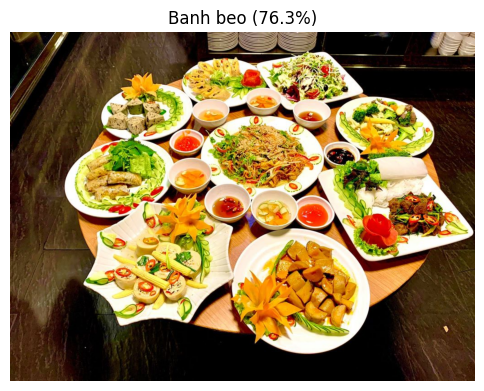

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(img_path).convert("RGB")

best_id = int(top_indices[0])
best_name = model.names[best_id]
best_score = top_scores[0] * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"{best_name} ({best_score:.1f}%)")
plt.show()


In [12]:
import csv

VAL_DIR = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_cls/val")
OUT_CSV = Path("yolo_cls33_val_preds.csv")

img_files = [p for p in VAL_DIR.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]
print("Tổng số ảnh val:", len(img_files))

with OUT_CSV.open("w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image_path", "true_class", "pred_class", "pred_prob"])

    for img_path in img_files:
        true_cls = img_path.parent.name  # tên folder là nhãn thật

        res = model.predict(
            source=str(img_path),
            imgsz=224,
            device=0,
            verbose=False
        )[0]

        probs = res.probs
        best_idx = int(probs.top1)
        pred_name = model.names[best_idx]
        pred_prob = float(probs.top1conf)

        writer.writerow([str(img_path), true_cls, pred_name, pred_prob])

print("✅ Đã lưu kết quả vào:", OUT_CSV)

Tổng số ảnh val: 3534


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: cHRM chunk does not match sRGB


✅ Đã lưu kết quả vào: yolo_cls33_val_preds.csv


Test image: /home/mtl/Downloads/6.jpg

🔥 Top 5 dự đoán:
- Banh can            : 58.57%
- Banh khot           : 17.96%
- Banh beo            : 15.92%
- Bun rieu            :  1.70%
- Bun bo Hue          :  1.00%

✅ Đã lưu ảnh có box tại: yolo_cls33_vis/6_cls.jpg


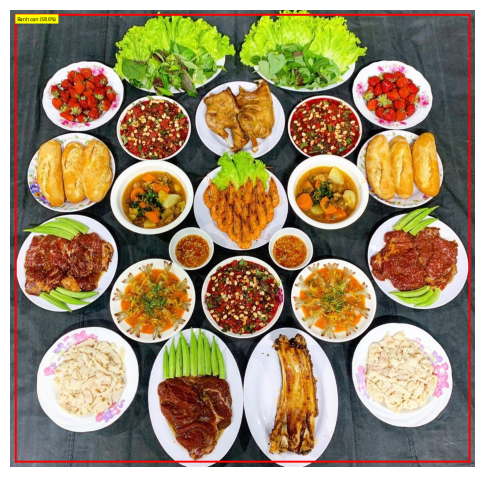

In [13]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import torch

# ==== CẤU HÌNH ====
# Ảnh input
img_path = Path("/home/mtl/Downloads/6.jpg")   # đổi sang ảnh ông muốn test

# Thư mục lưu ảnh đã vẽ box
OUT_DIR = Path("yolo_cls33_vis")
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / f"{img_path.stem}_cls.jpg"

print("Test image:", img_path)

# ==== 1. PREDICT ====
results = model.predict(
    source=str(img_path),
    imgsz=224,      # cùng kích thước train
    device=0,       # 0 = GPU, nếu lỗi CUDA thì nó tự fallback CPU
    verbose=False
)

res = results[0]
probs = res.probs            # Probs object
prob_tensor = probs.data     # Tensor xác suất [num_classes]

# Lấy top-5 (nếu cần), còn vẽ thì dùng top-1
top_k = 5
scores, indices = torch.topk(prob_tensor, k=top_k)

best_idx    = int(indices[0])
best_score  = float(scores[0])
best_name   = model.names[best_idx]

print(f"\n🔥 Top {top_k} dự đoán:")
for idx, score in zip(indices.cpu().numpy(), scores.cpu().numpy()):
    name = model.names[int(idx)]
    print(f"- {name:20s}: {score*100:5.2f}%")

# ==== 2. VẼ BOX + LABEL LÊN ẢNH ====
img = Image.open(img_path).convert("RGB")
draw = ImageDraw.Draw(img)
w, h = img.size

# Vẽ khung quanh toàn bộ ảnh cho có “box”
margin = 10
draw.rectangle(
    [margin, margin, w - margin, h - margin],
    outline="red",
    width=4,
)

label = f"{best_name} ({best_score*100:.1f}%)"

# Chọn font (arial nếu có, không thì font default)
try:
    font = ImageFont.truetype("arial.ttf", 24)
except:
    font = ImageFont.load_default()

# Tính kích thước text bằng textbbox (tránh lỗi textsize)
bbox = draw.textbbox((0, 0), label, font=font)
text_w = bbox[2] - bbox[0]
text_h = bbox[3] - bbox[1]

text_x = margin + 5
text_y = margin + 5

# Vẽ nền vàng cho text
draw.rectangle(
    [text_x - 4, text_y - 4, text_x + text_w + 4, text_y + text_h + 4],
    fill="yellow",
)
# Vẽ chữ
draw.text((text_x, text_y), label, font=font, fill="black")

# ==== 3. LƯU & HIỂN THỊ ====
img.save(out_path)
print("\n✅ Đã lưu ảnh có box tại:", out_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()


In [15]:
from pathlib import Path
from ultralytics import YOLO

# 🔹 ĐƯỜNG DẪN CẦN CHỈNH LẠI CHO ĐÚNG
# Thư mục YOLO auto-split khi train (log có dòng: Splits saved in ... Images_split ✅)
CLS_ROOT = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split")

VAL_DIR = CLS_ROOT / "val"   # dùng val như tập test đánh giá
TRAIN_DIR = CLS_ROOT / "train"

print("VAL_DIR:", VAL_DIR, "tồn tại?", VAL_DIR.exists())
print("TRAIN_DIR:", TRAIN_DIR, "tồn tại?", TRAIN_DIR.exists())

# Thư mục lưu run YOLO-CLS
RUNS_ROOT   = Path("runs_yolo_cls33")   # hoặc đúng tên thư mục anh đang có
RUN_NAME    = "MTL_FOOD33_CLS_01"
BEST_WEIGHTS = RUNS_ROOT / RUN_NAME / "weights" / "best.pt"

print("BEST_WEIGHTS:", BEST_WEIGHTS, "tồn tại?", BEST_WEIGHTS.exists())

# 🔹 Load model đã train
model = YOLO(str(BEST_WEIGHTS))
print("✅ Loaded YOLO-CLS:", BEST_WEIGHTS)


VAL_DIR: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split/val tồn tại? False
TRAIN_DIR: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split/train tồn tại? False
BEST_WEIGHTS: runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt tồn tại? True
✅ Loaded YOLO-CLS: runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt


In [16]:
# Val nhanh trên tập val
metrics = model.val(
    data=str(VAL_DIR),  # YOLO-CLS yêu cầu truyền FOLDER, không phải .yaml
    imgsz=224,          # giống lúc train
    device=0            # 0 = GPU, nếu lỗi nó tự fallback CPU
)

print("✅ DONE model.val()")

# metrics là 1 SimpleNamespace
print("Top-1 accuracy:", metrics.top1)
print("Top-5 accuracy:", metrics.top5)
print("Tốc độ (ms/image):", metrics.speed)


Ultralytics 8.3.229 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (Quadro RTX 5000, 15925MiB)
YOLO11n-cls summary (fused): 47 layers, 1,569,578 parameters, 0 gradients, 3.2 GFLOPs

WARNING ⚠️ Dataset not found, missing path /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split/val, attempting download...
WARNING ⚠️ Download failure, retrying 1/3 https://ultralytics.com/assets/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split/val.zip... URL can't contain control characters. '/ultralytics/assets/releases/download/v0.0.0//media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split/val.zip' (found at least ' ')
WARNING ⚠️ Download failure, retrying 2/3 https://ultralytics.com/assets/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split/val.zip... Curl return value 3
WARNING ⚠️ Download failure, retrying 3/3 https://ultralytics.com/assets/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split/val.zip... Curl return value 3


curl: (3) URL using bad/illegal format or missing URL
curl: (3) URL using bad/illegal format or missing URL
curl: (3) URL using bad/illegal format or missing URL


ConnectionError: ❌  Download failure for https://ultralytics.com/assets/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images_split/val.zip. Retry limit reached. Curl return value 3

In [6]:
from ultralytics import YOLO
from pathlib import Path

DET_WEIGHTS = Path("MTL_FOOD_PLATE_01/weights/best.pt")
CLS_WEIGHTS = Path("runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt")

det_model = YOLO(DET_WEIGHTS)   # model detect nhiều món trên bàn
cls_model = YOLO(CLS_WEIGHTS)   # model phân loại 33 món

print("✅ Loaded detector:", DET_WEIGHTS)
print("✅ Loaded classifier:", CLS_WEIGHTS)
print("Số lớp classifier:", len(cls_model.names))
print(cls_model.names)


✅ Loaded detector: MTL_FOOD_PLATE_01/weights/best.pt
✅ Loaded classifier: runs_yolo_cls33/MTL_FOOD33_CLS_01/weights/best.pt
Số lớp classifier: 34
{0: 'Banh beo', 1: 'Banh bot loc', 2: 'Banh can', 3: 'Banh canh', 4: 'Banh chung', 5: 'Banh cuon', 6: 'Banh duc', 7: 'Banh gio', 8: 'Banh khot', 9: 'Banh mi', 10: 'Banh pia', 11: 'Banh tet', 12: 'Banh trang nuong', 13: 'Banh xeo', 14: 'Bun bo Hue', 15: 'Bun dau mam tom', 16: 'Bun mam', 17: 'Bun rieu', 18: 'Bun thit nuong', 19: 'Ca kho to', 20: 'Canh chua', 21: 'Cao lau', 22: 'Chao long', 23: 'Com tam', 24: 'Goi cuon', 25: 'Hu tieu', 26: 'Mi quang', 27: 'Nem chua', 28: 'Pho', 29: 'Xoi xeo', 30: 'banh_da_lon', 31: 'banh_tieu', 32: 'banh_trung_thu', 33: 'chuot_dong_nuong'}


Test image: /home/mtl/Downloads/An-Lac-Tam-1.jpg
🔍 Số box detect được: 10
✅ Đã lưu ảnh detect + classify tại: images/detect_foods_yolo_cls33/An-Lac-Tam-1_det_cls33.jpg


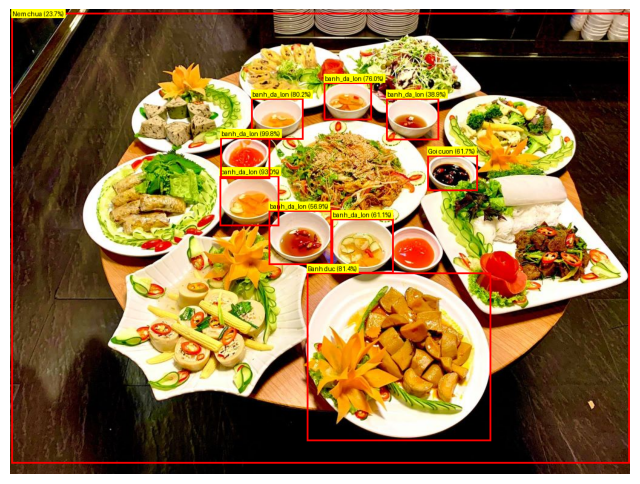

In [14]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import torch
import numpy as np

# Ảnh input
img_path = Path("/home/mtl/Downloads/An-Lac-Tam-1.jpg")

# Thư mục lưu ảnh output
OUT_DIR = Path("images/detect_foods_yolo_cls33")
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / f"{img_path.stem}_det_cls33.jpg"

print("Test image:", img_path)

# ==== 1. LOAD ẢNH GỐC ====
orig_img = Image.open(img_path).convert("RGB")
img_np   = np.array(orig_img)  # YOLO detect dùng numpy

# ==== 2. DETECT CÁC DĨA / MÓN TRÊN BÀN ====
det_res = det_model.predict(
    source=img_np,
    conf=0.7,
    device=0,
    verbose=False
)[0]

boxes = det_res.boxes
print("🔍 Số box detect được:", len(boxes))

# ==== 3. LOOP TỪNG BOX → CROP → CLASSIFY ====
draw = ImageDraw.Draw(orig_img)

try:
    font = ImageFont.truetype("arial.ttf", 20)
except:
    font = ImageFont.load_default()

for i, box in enumerate(boxes):
    x1, y1, x2, y2 = box.xyxy[0].cpu().tolist()
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    # Crop vùng món ăn
    crop = orig_img.crop((x1, y1, x2, y2))

    # YOLO-CLS accept numpy / PIL đều được
    cls_res = cls_model.predict(
        source=np.array(crop),
        imgsz=224,
        device=0,
        verbose=False
    )[0]

    probs = cls_res.probs
    prob_tensor = probs.data

    score, idx = torch.max(prob_tensor, dim=0)
    score = float(score)
    cls_id = int(idx)
    name = cls_model.names[cls_id]

    # ==== 4. VẼ BOX + LABEL CHO TỪNG MÓN ====
    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

    label = f"{name} ({score*100:.1f}%)"

    # nền label
    bbox = draw.textbbox((0, 0), label, font=font)
    tw = bbox[2] - bbox[0]
    th = bbox[3] - bbox[1]
    tx = x1
    ty = max(0, y1 - th - 4)

    draw.rectangle([tx, ty, tx + tw + 4, ty + th + 4], fill="yellow")
    draw.text((tx + 2, ty + 2), label, font=font, fill="black")

# ==== 5. LƯU & SHOW ẢNH ====
orig_img.save(out_path)
print("✅ Đã lưu ảnh detect + classify tại:", out_path)

plt.figure(figsize=(8, 8))
plt.imshow(orig_img)
plt.axis("off")
plt.show()
